In [1]:
# Project 4: Insight Discovery through EDA

# Extract insights that matter

# Identify key trends, risks, & opportunities

# Perform detailed EDA on a real dataset

# Translate findings into business language

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n_records = 500
cities = ['Mumbai', 'Delhi', 'Bangalore', 'Jaipur', 'Tonk']

eda_data = {
    'TransactionID': [f'TXN-{i:03d}' for i in range(1, n_records + 1)],
    'City': np.random.choice(cities, n_records, p=[0.35, 0.25, 0.20, 0.12, 0.08]),
    'Order_Amount_INR': np.random.exponential(scale=2500, size=n_records) + 500,
    'Customer_Rating': np.random.choice([1, 2, 3, 4, 5], n_records, p=[0.05, 0.10, 0.20, 0.40, 0.25]),
    'Support_Escalations': np.random.poisson(lam=0.8, size=n_records)
}

df_eda = pd.DataFrame(eda_data)
df_eda['Order_Amount_INR'] = df_eda['Order_Amount_INR'].round(2)

df_eda.head()

,TransactionID,City,Order_Amount_INR,Customer_Rating,Support_Escalations
0,TXN-001,Delhi,3494.66,3,1
1,TXN-002,Tonk,2420.20,4,0
2,TXN-003,Bangalore,1425.95,5,0
3,TXN-004,Delhi,4702.27,4,0
4,TXN-005,Mumbai,3385.82,5,0


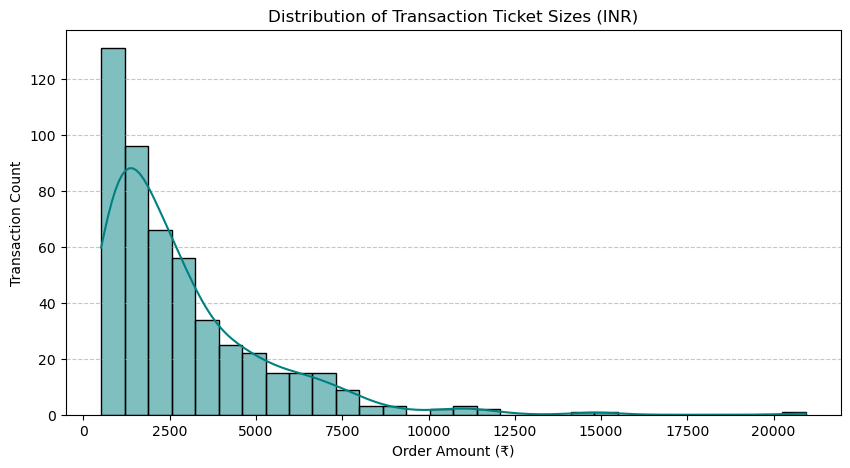

count      500.000000
mean      2851.756920
std       2427.320933
min        511.610000
25%       1150.487500
50%       2095.800000
75%       3739.662500
max      20931.110000
Name: Order_Amount_INR, dtype: float64

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df_eda['Order_Amount_INR'], kde=True, color='teal', bins=30)
plt.title('Distribution of Transaction Ticket Sizes (INR)')
plt.xlabel('Order Amount (₹)')
plt.ylabel('Transaction Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

df_eda['Order_Amount_INR'].describe()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24356\2749131941.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Revenue_INR', y='City', data=city_performance, palette='viridis')


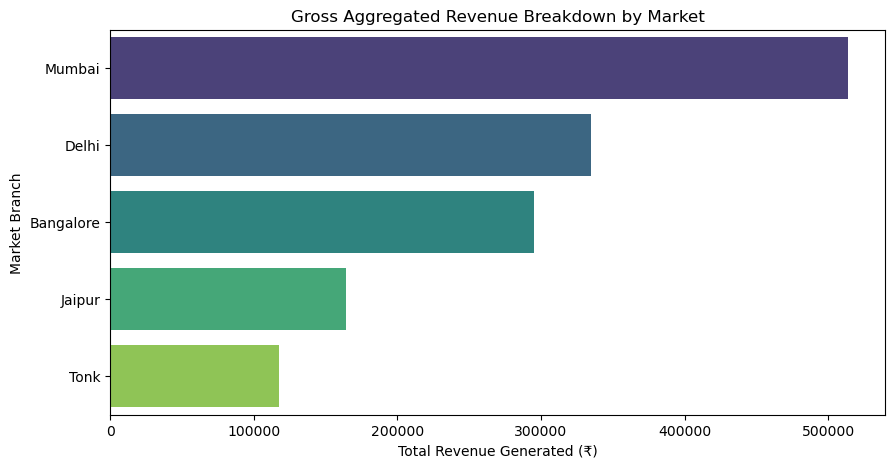

,City,Total_Revenue_INR,Average_Ticket_INR,Transaction_Volume
0,Mumbai,513970.81,2871.345307,179
1,Delhi,334722.73,2936.164298,114
2,Bangalore,294910.17,2919.902673,101
3,Jaipur,164368.54,2651.105484,62
4,Tonk,117906.21,2679.686591,44


In [5]:
city_performance = df_eda.groupby('City').agg(
    Total_Revenue_INR=('Order_Amount_INR', 'sum'),
    Average_Ticket_INR=('Order_Amount_INR', 'mean'),
    Transaction_Volume=('TransactionID', 'count')
).sort_values(by='Total_Revenue_INR', ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Total_Revenue_INR', y='City', data=city_performance, palette='viridis')
plt.title('Gross Aggregated Revenue Breakdown by Market')
plt.xlabel('Total Revenue Generated (₹)')
plt.ylabel('Market Branch')
plt.show()

city_performance

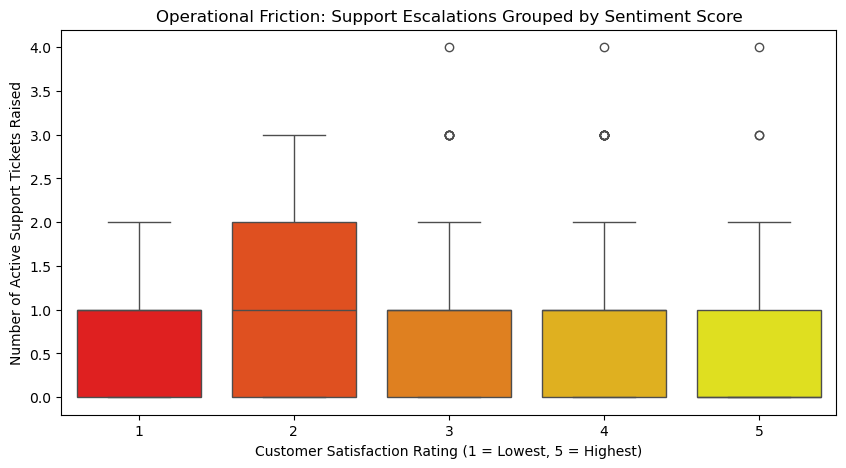

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Customer_Rating', y='Support_Escalations', data=df_eda, palette='autumn', hue='Customer_Rating', legend=False)
plt.title('Operational Friction: Support Escalations Grouped by Sentiment Score')
plt.xlabel('Customer Satisfaction Rating (1 = Lowest, 5 = Highest)')
plt.ylabel('Number of Active Support Tickets Raised')
plt.show()